# Day 55: Logistic Regression — sklearn + Evaluation Metrics
**Phase 4 · Machine Learning** | Dataset: FC Lahore Lions (synthetic, seed = 42)

## Objective
By the end of this notebook I should be able to:
- Fit a logistic regression with sklearn (`.fit()`, `.predict()`, `.predict_proba()`)
- Build a **confusion matrix** by hand first, then with `confusion_matrix()`
- Compute **precision, recall and F1** and explain each in plain words
- Explain why **accuracy alone can mislead**, and when recall or precision matters more

## Imports

In [1]:
# numpy and pandas for data
import numpy as np
import pandas as pd

# matplotlib for charts
import matplotlib.pyplot as plt

# the model and the tools to split and evaluate
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score,
                             recall_score, f1_score)

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True

## Theory
- **Recap (Day 54):** logistic regression = linear score `z` -> sigmoid -> probability -> threshold -> class.
- **Today:** sklearn does the training for us, so we focus on **evaluating** the model.
- **`.fit(X_train, y_train)`** learns the weights. **`.predict(X_test)`** returns classes (0/1). **`.predict_proba(X_test)`** returns probabilities.
- **Confusion matrix** counts four outcomes:
  - **TP** (true positive): predicted win, was a win
  - **TN** (true negative): predicted no win, was no win
  - **FP** (false positive): predicted win, was NOT a win (false alarm)
  - **FN** (false negative): predicted no win, was a win (missed win)
- **Precision** = `TP / (TP + FP)`: of the wins I *called*, how many were real?
- **Recall** = `TP / (TP + FN)`: of the real wins, how many did I *catch*?
- **F1** = the balance (harmonic mean) of precision and recall.
- **Accuracy** = `(TP + TN) / everything`. It can look great on rare events while the model is useless.

**Football picture:** precision is a striker's shot accuracy (of the shots taken, how many were on target). Recall is chance conversion (of all the chances that appeared, how many were taken).

**Draw on paper first:** sketch a 2x2 grid with *Actual* down the side and *Predicted* across the top, then fill TN, FP, FN, TP.

## Example 1: Fit, Predict and predict_proba

In [2]:
# Build a synthetic dataset: 300 matches, two features, one 0/1 target
rng = np.random.default_rng(42)                       # seed = 42 so results repeat
n_matches = 300
shots = rng.integers(0, 13, size=n_matches)           # shots on target: 0 to 12
possession = rng.integers(35, 66, size=n_matches)     # possession %: 35 to 65
z = 0.55 * shots + 0.06 * (possession - 50) - 3.2     # hidden "real" score
won = rng.binomial(1, 1 / (1 + np.exp(-z)))           # 1 = win, 0 = no win

df = pd.DataFrame({
    "match_id": np.arange(1, n_matches + 1),
    "shots_on_target": shots,
    "possession_pct": possession,
    "won": won
})

# Save next to the notebook, then read it back
df.to_csv("day_55_fc_lahore_lions_matches.csv", index=False)
df = pd.read_csv("day_55_fc_lahore_lions_matches.csv")

print(df.head())
print("\nWin rate:", round(df["won"].mean(), 3))

   match_id  shots_on_target  possession_pct  won
0         1                1              46    0
1         2               10              60    1
2         3                8              35    1
3         4                5              62    1
4         5                5              51    1

Win rate: 0.527


In [3]:
# Split into features (X) and target (y)
X = df[["shots_on_target", "possession_pct"]]
y = df["won"]

# 75% train / 25% test. stratify keeps the win rate similar in both parts.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Train rows:", len(X_train), "| Test rows:", len(X_test))

Train rows: 225 | Test rows: 75


In [4]:
# Fit on TRAIN data only, then predict on unseen TEST data
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)                 # predicted classes (0/1)
print("Predicted:", y_pred[:10])
print("Actual:   ", y_test.values[:10])

# The learned weights (one per feature) and the bias
print("\nWeights:", model.coef_.round(3), "| Bias:", model.intercept_.round(3))

Predicted: [0 0 0 0 0 1 0 1 0 1]
Actual:    [0 0 0 0 0 1 0 1 1 1]

Weights: [[0.608 0.064]] | Bias: [-6.697]


In [5]:
# predict_proba returns TWO columns: [P(no win), P(win)]
proba = model.predict_proba(X_test)
print(proba[:3].round(3))

# predict() is simply "P(win) > 0.5" (the Day 54 threshold)
same = ((proba[:, 1] > 0.5).astype(int) == y_pred).all()
print("predict() matches threshold 0.5:", same)

[[0.506 0.494]
 [0.844 0.156]
 [0.959 0.041]]
predict() matches threshold 0.5: True


## Example 2: Confusion Matrix, Precision, Recall and F1

### 2A. Confusion matrix

In [6]:
# Rows = ACTUAL class, columns = PREDICTED class
cm = confusion_matrix(y_test, y_pred)
print(cm)

# ravel() flattens the 2x2 grid in this order: TN, FP, FN, TP
tn, fp, fn, tp = cm.ravel()
print("TN:", tn, "| FP:", fp, "| FN:", fn, "| TP:", tp)

[[30  5]
 [ 7 33]]
TN: 30 | FP: 5 | FN: 7 | TP: 33


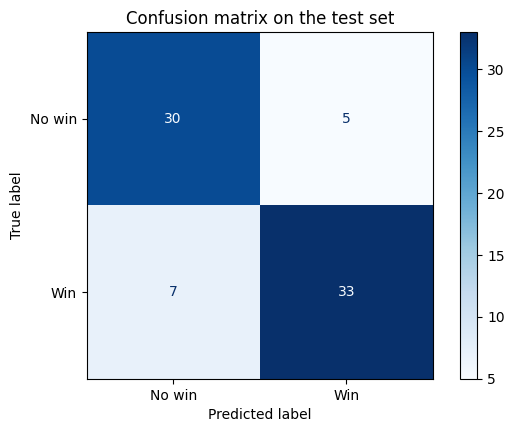

In [7]:
# Chart: the confusion matrix as a heatmap
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No win", "Win"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix on the test set")
plt.grid(False)
plt.savefig("images/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### 2B. Precision, recall and F1

In [8]:
# sklearn's metric functions
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", round(precision, 3))
print("Recall:   ", round(recall, 3))
print("F1:       ", round(f1, 3))

# Check by hand from the confusion matrix - the numbers must match
print("\nPrecision by hand:", round(tp / (tp + fp), 3))
print("Recall by hand:   ", round(tp / (tp + fn), 3))

Precision: 0.868
Recall:    0.825
F1:        0.846

Precision by hand: 0.868
Recall by hand:    0.825


### 2C. The accuracy trap

In [9]:
# 100 matches, only 5 hat-tricks (a rare event)
y_true_rare = np.array([1] * 5 + [0] * 95)

# A "lazy" model that ALWAYS predicts "no hat-trick"
lazy_pred = np.zeros(100, dtype=int)

print("Accuracy:", accuracy_score(y_true_rare, lazy_pred))   # looks great
print("Recall:  ", recall_score(y_true_rare, lazy_pred))     # catches nothing

Accuracy: 0.95
Recall:   0.0


### 2D. Moving the threshold: precision vs recall

In [10]:
# P(win) for every test match
p_win = proba[:, 1]

# Try three thresholds and compare precision and recall
print("threshold | precision | recall")
for t in [0.3, 0.5, 0.7]:
    pred_t = (p_win > t).astype(int)
    p = precision_score(y_test, pred_t)
    r = recall_score(y_test, pred_t)
    print(f"{t:>9} | {p:>9.2f} | {r:>6.2f}")

threshold | precision | recall
      0.3 |      0.77 |   0.93
      0.5 |      0.87 |   0.82
      0.7 |      0.87 |   0.68


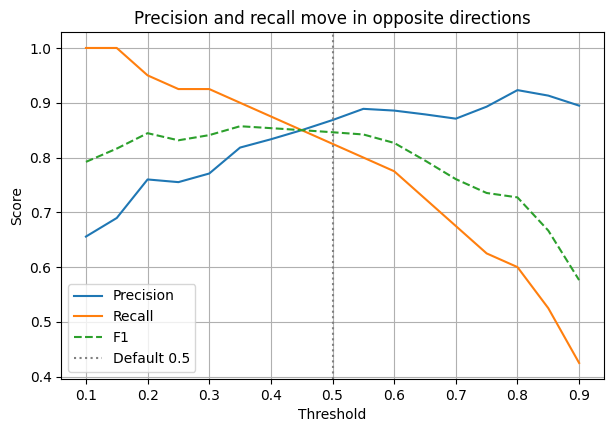

In [11]:
# Chart: precision, recall and F1 across many thresholds
thresholds = np.arange(0.1, 0.91, 0.05)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    pred_t = (p_win > t).astype(int)
    precisions.append(precision_score(y_test, pred_t))
    recalls.append(recall_score(y_test, pred_t))
    f1s.append(f1_score(y_test, pred_t))

plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1s, label="F1", linestyle="--")
plt.axvline(0.5, color="grey", linestyle=":", label="Default 0.5")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and recall move in opposite directions")
plt.legend()
plt.savefig("images/precision_recall_threshold.png", dpi=150, bbox_inches="tight")
plt.show()

## Practice Exercise
**Your turn (Practice).** Draw the 2x2 grid on paper first, then check with code.
1. Actual: `[1, 0, 1, 1, 0, 0, 1, 0]`, predicted: `[1, 0, 0, 1, 1, 0, 1, 0]`
2. Count TP, TN, FP, FN by hand.
3. Work out precision and recall by hand.
4. Confirm with `confusion_matrix`, `precision_score` and `recall_score`.

In [12]:
# Your attempt here

In [13]:
# Worked answer
actual = [1, 0, 1, 1, 0, 0, 1, 0]
predicted = [1, 0, 0, 1, 1, 0, 1, 0]

tn_p, fp_p, fn_p, tp_p = confusion_matrix(actual, predicted).ravel()
print("TN:", tn_p, "| FP:", fp_p, "| FN:", fn_p, "| TP:", tp_p)
print("Precision:", round(precision_score(actual, predicted), 3))
print("Recall:   ", round(recall_score(actual, predicted), 3))

TN: 3 | FP: 1 | FN: 1 | TP: 3
Precision: 0.75
Recall:    0.75


## Mini Challenge
**Screening mode.** Imagine a medical-style screening where **missing a real case is terrible**. Loop over thresholds from 0.1 to 0.9 (step 0.05) and find the **highest threshold that still gives recall of at least 0.90**. Report the precision you pay at that threshold.

In [14]:
# Mini Challenge solution
best_t = None
for t in np.arange(0.1, 0.91, 0.05):
    pred_t = (p_win > t).astype(int)
    if recall_score(y_test, pred_t) >= 0.90:
        best_t = round(t, 2)                 # keeps updating, so it ends on the highest valid t

if best_t is None:
    print("No threshold reaches recall 0.90 on this test set")
else:
    pred_best = (p_win > best_t).astype(int)
    print("Highest threshold with recall >= 0.90:", best_t)
    print("Recall:   ", round(recall_score(y_test, pred_best), 3))
    print("Precision:", round(precision_score(y_test, pred_best), 3))

Highest threshold with recall >= 0.90: 0.35
Recall:    0.9
Precision: 0.818


## Summary
- `.fit()` learns from the training set, `.predict()` gives classes, `.predict_proba()` gives probabilities.
- The **confusion matrix** (TN, FP, FN, TP) is the base for every other classification metric.
- **Precision** = of my predicted positives, how many were right. **Recall** = of the real positives, how many I found. **F1** balances the two.
- **Accuracy can mislead** on rare events: a lazy model reached high accuracy with zero recall.
- Lowering the threshold raises recall and lowers precision. Pick the threshold based on which mistake costs more.
- **Next: Day 56 — KNN, distance-based intuition.**